<a href="https://colab.research.google.com/github/TanuSree02/Deep-learning/blob/main/XOR_GATE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial parameters
b1: [[0. 0.]]
b2: [[0.]]
w1: [[-0.25091976  0.90142861]
 [ 0.46398788  0.19731697]]
w2: [[-0.68796272]
 [-0.68801096]]

Training XOR neural network
Epoch 0 loss = 0.5005
Epoch 2000 loss = 0.4999
Epoch 4000 loss = 0.4998
Epoch 6000 loss = 0.4995
Epoch 8000 loss = 0.4985

Training completed

Final predictions
[0 0] -> 1
[0 1] -> 0
[1 0] -> 1
[1 1] -> 0


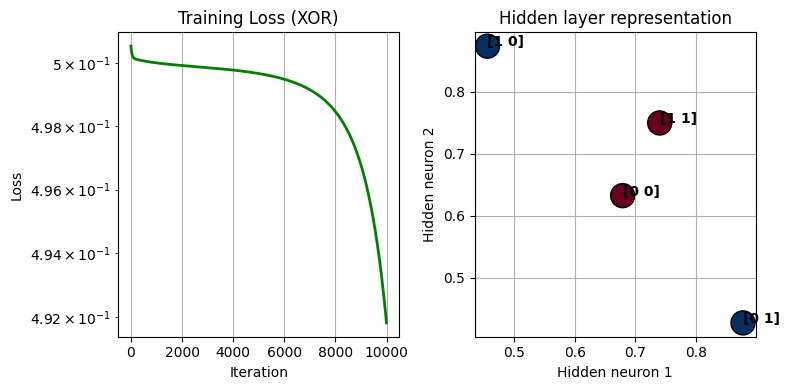

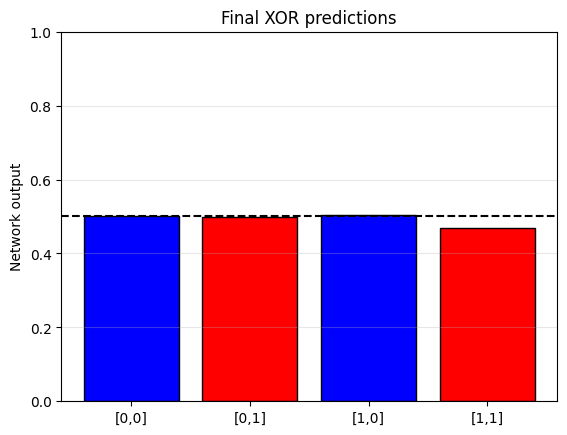

Accuracy: 50.0 %


In [1]:
import numpy as np
import matplotlib.pyplot as plt

input_size = 2
hidden_size = 2
output_size = 1

learning_rate = 0.05
iterations = 10000
print_interval = 2000


# XOR data

x = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])


np.random.seed(42)


# weights

w1 = np.random.uniform(-1,1,(input_size,hidden_size))
w2 = np.random.uniform(-1,1,(hidden_size,output_size))

b1 = np.zeros((1,hidden_size))
b2 = np.zeros((1,output_size))


print("Initial parameters")
print("b1:",b1)
print("b2:",b2)
print("w1:",w1)
print("w2:",w2)



# sigmoid

def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z,-250,250)))


def sigmoid_derivative(a):
    return a*(1-a)



# forward pass

def forward_pass(x,w1,b1,w2,b2):

    z1 = np.dot(x,w1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1,w2) + b2
    output = sigmoid(z2)

    return output,a1,z1,z2



loss_history = []


print("\nTraining XOR neural network")


for i in range(iterations):

    z1 = np.dot(x,w1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1,w2) + b2
    output = sigmoid(z2)

    error = y - output

    loss = np.mean(np.abs(error))
    loss_history.append(loss)


    # backprop

    d_output = error * sigmoid_derivative(output)

    d_hidden = np.dot(d_output,w2.T) * sigmoid_derivative(a1)


    w2 += learning_rate * np.dot(a1.T,d_output)
    b2 += learning_rate * np.sum(d_output,axis=0,keepdims=True)

    w1 += learning_rate * np.dot(x.T,d_hidden)
    b1 += learning_rate * np.sum(d_hidden,axis=0,keepdims=True)


    if i % print_interval == 0:
        print(f"Epoch {i} loss = {loss:.4f}")


print("\nTraining completed")


final_output,final_a,_,_ = forward_pass(x,w1,b1,w2,b2)


print("\nFinal predictions")

for i in range(len(x)):

    pred = 1 if final_output[i,0] > 0.5 else 0

    print(x[i], "->", pred)



# -------------------
# LOSS PLOT
# -------------------

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.semilogy(loss_history,'g',linewidth=2)
plt.title("Training Loss (XOR)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)



# -------------------
# HIDDEN LAYER PLOT
# -------------------

plt.subplot(1,2,2)

scatter = plt.scatter(
    final_a[:,0],
    final_a[:,1],
    c=y.flatten(),
    s=300,
    cmap="RdBu",
    edgecolors="black"
)

for i in range(len(x)):
    plt.text(
        final_a[i,0],
        final_a[i,1],
        str(x[i]),
        fontsize=10,
        fontweight="bold"
    )

plt.xlabel("Hidden neuron 1")
plt.ylabel("Hidden neuron 2")
plt.title("Hidden layer representation")
plt.grid(True)

plt.tight_layout()
plt.show()



# -------------------
# BAR OUTPUT PLOT
# -------------------

colors = ["red" if v<0.5 else "blue" for v in final_output.flatten()]

plt.bar(
    range(4),
    final_output.flatten(),
    color=colors,
    edgecolor="black"
)

plt.axhline(0.5,color="black",linestyle="--")

plt.xticks(range(4),["[0,0]","[0,1]","[1,0]","[1,1]"])

plt.ylabel("Network output")
plt.title("Final XOR predictions")

plt.ylim(0,1)

plt.grid(axis="y",alpha=0.3)

plt.show()


# accuracy

predictions = (final_output > 0.5).astype(int)
accuracy = np.mean(predictions == y) * 100

print("Accuracy:",accuracy,"%")